# Part 2: ResNet-18 Model Improvement Ablations

This notebook keeps the Part 2 workflow notebook-owned while moving reusable training and result logic into project modules. The regular-training baseline is loaded from Part 1 results; the remaining ablations are trained here.

In [1]:
from pathlib import Path
import importlib
import os
import sys


In [2]:
from pathlib import Path
import importlib
import sys


_REQUIRED_PROJECT_FILES = (
    Path('src/__init__.py'),
    Path('src/utils/notebook_setup.py'),
    Path('src/evaluation/experiment_results.py'),
)


def _mount_colab_drive_if_available():
    try:
        from google.colab import drive  # type: ignore
    except ImportError:
        return
    drive.mount('/content/drive')


def _path_looks_like_project_root(path):
    return all((path / required).is_file() for required in _REQUIRED_PROJECT_FILES)


def _candidate_project_roots():
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    candidates.extend([
        Path('/content/drive/MyDrive/MLDS_Final_Project'),
        Path('/content/MLDS_Final_Project'),
        Path('/content/drive/MyDrive/Colab Notebooks/MLDS_Final_Project'),
    ])
    my_drive = Path('/content/drive/MyDrive')
    if my_drive.exists():
        candidates.extend(my_drive.glob('MLDS_Final_Project'))
        candidates.extend(my_drive.glob('*/MLDS_Final_Project'))
    return candidates


def _find_project_root():
    seen = set()
    for candidate in _candidate_project_roots():
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if _path_looks_like_project_root(candidate):
            return candidate
    return None


def _module_file(module_name):
    module = sys.modules.get(module_name)
    module_file = getattr(module, '__file__', None)
    if module_file is None:
        return None
    try:
        return Path(module_file).resolve()
    except OSError:
        return None


def _clear_stale_src_modules(project_root):
    expected_src = project_root / 'src'
    for module_name in list(sys.modules):
        if module_name != 'src' and not module_name.startswith('src.'):
            continue
        module_file = _module_file(module_name)
        if module_file is None:
            sys.modules.pop(module_name, None)
            continue
        try:
            module_file.relative_to(expected_src)
        except ValueError:
            sys.modules.pop(module_name, None)


_PROJECT_ROOT = _find_project_root()
if _PROJECT_ROOT is None:
    _mount_colab_drive_if_available()
    _PROJECT_ROOT = _find_project_root()

if _PROJECT_ROOT is None:
    raise ModuleNotFoundError(
        'Could not find the full MLDS_Final_Project repo. Expected '
        'src/__init__.py, src/utils/notebook_setup.py, and '
        'src/evaluation/experiment_results.py. In Colab, upload or clone '
        'the full repo, or place it at /content/drive/MyDrive/MLDS_Final_Project.'
    )

if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))
_clear_stale_src_modules(_PROJECT_ROOT)
importlib.invalidate_caches()

notebook_setup = importlib.import_module('src.utils.notebook_setup')
ROOT = notebook_setup.bootstrap_notebook(_PROJECT_ROOT)
ROOT


/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.10.18
Package versions:
  numpy: 1.26.4
  pandas: 2.1.4
  scipy: 1.11.4
  scikit-learn: 1.7.2
  torch: 2.5.1
  torchvision: 0.20.1
  timm: 1.0.26
  pyyaml: 6.0.3
torch.cuda.is_available(): False
Project root: /Users/royrubin/Documents/GitHub/MLDS_Final_Project


PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project')

In [3]:
import pandas as pd
from IPython.core.display import Image
from IPython.display import display

import src.evaluation.experiment_results as experiment_results

experiment_results = importlib.reload(experiment_results)


In [4]:
import src.experiments.part2 as part2_experiments

part2_experiments = importlib.reload(part2_experiments)
load_part1_model_baseline_aggregated = experiment_results.load_part1_model_baseline_aggregated
run_part2_improvement_experiments = part2_experiments.run_part2_improvement_experiments


## Configuration

In [5]:
part2_setup = notebook_setup.setup_part2_config()
config = part2_setup.config
device = part2_setup.device
output_paths = part2_setup.output_paths
part2_setup.summary


Selected device: cpu
Python: 3.10.18
Package versions:
  numpy: 1.26.4
  pandas: 2.1.4
  scipy: 1.11.4
  scikit-learn: 1.7.2
  torch: 2.5.1
  torchvision: 0.20.1
  timm: 1.0.26
  pyyaml: 6.0.3
torch.cuda.is_available(): False
Selected device: cpu


,part,config_name,model_name,tiles_per_side_values,num_tile_permutations,epochs,batch_size,num_workers,use_amp,device
0,part2,part2_improvement,resnet18,"[1, 4]",2,1,16,2,False,cpu


In [6]:
pd.DataFrame(config.ablations)

,name,use_pretrained,augmentation,curriculum
0,augmentation_combined_augmentations,True,combined_augmentations,NaN
1,augmentation_patch_shuffle,True,patch_shuffle,NaN
2,augmentation_random_erasing,True,random_erasing,NaN
3,augmentation_same_label_cutmix,True,same_label_cutmix,NaN
4,curriculum_corruption_probability,True,none,corruption_probability
5,curriculum_permutation_difficulty,True,none,permutation_difficulty


## Part 1 ResNet-18 Baseline

In [7]:
part1_baseline_aggregated = load_part1_model_baseline_aggregated(config, config.model_name)
if not part1_baseline_aggregated.empty:
    display(part1_baseline_aggregated)

,model_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs,ablation_name,config_name
0,resnet18,4.0,16,0.903846,0.0,0.903846,0.0,2,regular_part1,part2_improvement
1,resnet18,NaN,1,0.865385,NaN,0.865385,NaN,1,regular_part1,part2_improvement


## Train Improvement Ablations

In [8]:
RUN_TRAINING = True

if RUN_TRAINING:
    part2_results = run_part2_improvement_experiments(config=config, device=device)
    display(part2_results)
else:
    print('Training is skipped. Set RUN_TRAINING = True to train Part 2 ablations in this notebook.')

Raw results path: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part2_raw_results.csv
Checkpointing disabled outside Google Colab.
Saved 18 pending row(s) for model 'resnet18'.

Running ablation: augmentation_combined_augmentations

[1/3]
model=resnet18, ablation=augmentation_combined_augmentations, tiles_per_side=None, tile_permutation_id=0, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...


resnet18 [augmentation_combined_augmentations] 1x1 permutation #0. epochs progress: 100%|██████████| 1/1 [01:11<00:00, 71.31s/epoch, best_val_accuracy=0.846, stage=standard, train_accuracy=0.76, train_loss=0.454, val_accuracy=0.846, val_loss=0.407]


Current run runtime: 1m 12s
Total training runtime: 1m 12s

[2/3]
model=resnet18, ablation=augmentation_combined_augmentations, tiles_per_side=4, tile_permutation_id=1, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...


resnet18 [augmentation_combined_augmentations] 4x4 permutation #1. epochs progress: 100%|██████████| 1/1 [00:44<00:00, 44.70s/epoch, best_val_accuracy=0.769, stage=standard, train_accuracy=0.721, train_loss=0.533, val_accuracy=0.769, val_loss=1.34]


Current run runtime: 45s
Total training runtime: 2m 17s

[3/3]
model=resnet18, ablation=augmentation_combined_augmentations, tiles_per_side=4, tile_permutation_id=2, seed=42
stages=1
1. standard: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Building model 'resnet18'...


...

resnet18 [curriculum_permutation_difficulty] 4x4 permutation #1. epochs progress: 100%|██████████| 4/4 [02:35<00:00, 38.92s/epoch, best_val_accuracy=0.923, stage=4x4_permutation, train_accuracy=0.897, train_loss=0.296, val_accuracy=0.808, val_loss=0.751]


Current run runtime: 2m 36s
Total training runtime: 28m 17s

[3/3]
model=resnet18, ablation=curriculum_permutation_difficulty, tiles_per_side=4, tile_permutation_id=2, seed=42
stages=4
1. original: 1 epoch
	2. 2x2_permutation: 1 epoch
	3. 3x3_permutation: 1 epoch
	4. 4x4_permutation: 1 epoch
Building dataloaders...
Built dataloaders: 
	train=204 samples in 13 batches
	validation=52 samples in 4 batches.
Stage dataloaders: original=204 samples / 13 batches; 2x2_permutation=204 samples / 13 batches; 3x3_permutation=204 samples / 13 batches; 4x4_permutation=204 samples / 13 batches.
Building model 'resnet18'...


resnet18 [curriculum_permutation_difficulty] 4x4 permutation #2. epochs progress: 100%|██████████| 4/4 [02:39<00:00, 39.97s/epoch, best_val_accuracy=0.904, stage=4x4_permutation, train_accuracy=0.926, train_loss=0.176, val_accuracy=0.904, val_loss=0.341]


Current run runtime: 2m 40s
Total training runtime: 31m 47s


,model_name,ablation_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,resnet18,augmentation_combined_augmentations,4.0,16,0.836538,0.095187,0.836538,0.095187,2
1,resnet18,augmentation_combined_augmentations,NaN,1,0.846154,NaN,0.846154,NaN,1
2,resnet18,augmentation_patch_shuffle,4.0,16,0.817308,0.095187,0.817308,0.095187,2
3,resnet18,augmentation_patch_shuffle,NaN,1,0.923077,NaN,0.923077,NaN,1
4,resnet18,augmentation_random_erasing,4.0,16,0.913462,0.013598,0.913462,0.013598,2
5,resnet18,augmentation_random_erasing,NaN,1,0.865385,NaN,0.865385,NaN,1
6,resnet18,augmentation_same_label_cutmix,4.0,16,0.798077,0.122384,0.798077,0.122384,2
7,resnet18,augmentation_same_label_cutmix,NaN,1,0.942308,NaN,0.942308,NaN,1
8,resnet18,curriculum_corruption_probability,4.0,16,0.884615,0.054393,0.913462,0.013598,2
9,resnet18,curriculum_corruption_probability,NaN,1,0.884615,NaN,0.923077,NaN,1


## Results

In [9]:
results_path = Path(output_paths['aggregated_results'])

if results_path.exists():
    part2_results = pd.read_csv(results_path)
    if 'regular_part1' not in set(part2_results.get('ablation_name', [])) and not part1_baseline_aggregated.empty:
        part2_results = pd.concat([part1_baseline_aggregated, part2_results], ignore_index=True, sort=False)
    display(part2_results.sort_values(['tiles_per_side', 'ablation_name']))
else:
    print('Part 2 aggregated results were not found. Set RUN_TRAINING = True and run the training cell.')
    if part1_baseline_aggregated.empty:
        print('Part 1 ResNet-18 baseline results were also not found; run Part 1 first to include regular_part1.')

,model_name,ablation_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,resnet18,augmentation_combined_augmentations,4.0,16,0.836538,0.095187,0.836538,0.095187,2
2,resnet18,augmentation_patch_shuffle,4.0,16,0.817308,0.095187,0.817308,0.095187,2
4,resnet18,augmentation_random_erasing,4.0,16,0.913462,0.013598,0.913462,0.013598,2
6,resnet18,augmentation_same_label_cutmix,4.0,16,0.798077,0.122384,0.798077,0.122384,2
8,resnet18,curriculum_corruption_probability,4.0,16,0.884615,0.054393,0.913462,0.013598,2
10,resnet18,curriculum_permutation_difficulty,4.0,16,0.855769,0.067991,0.913462,0.013598,2
12,resnet18,regular_part1,4.0,16,0.903846,0.000000,0.903846,0.000000,2
1,resnet18,augmentation_combined_augmentations,NaN,1,0.846154,NaN,0.846154,NaN,1
3,resnet18,augmentation_patch_shuffle,NaN,1,0.923077,NaN,0.923077,NaN,1
5,resnet18,augmentation_random_erasing,NaN,1,0.865385,NaN,0.865385,NaN,1


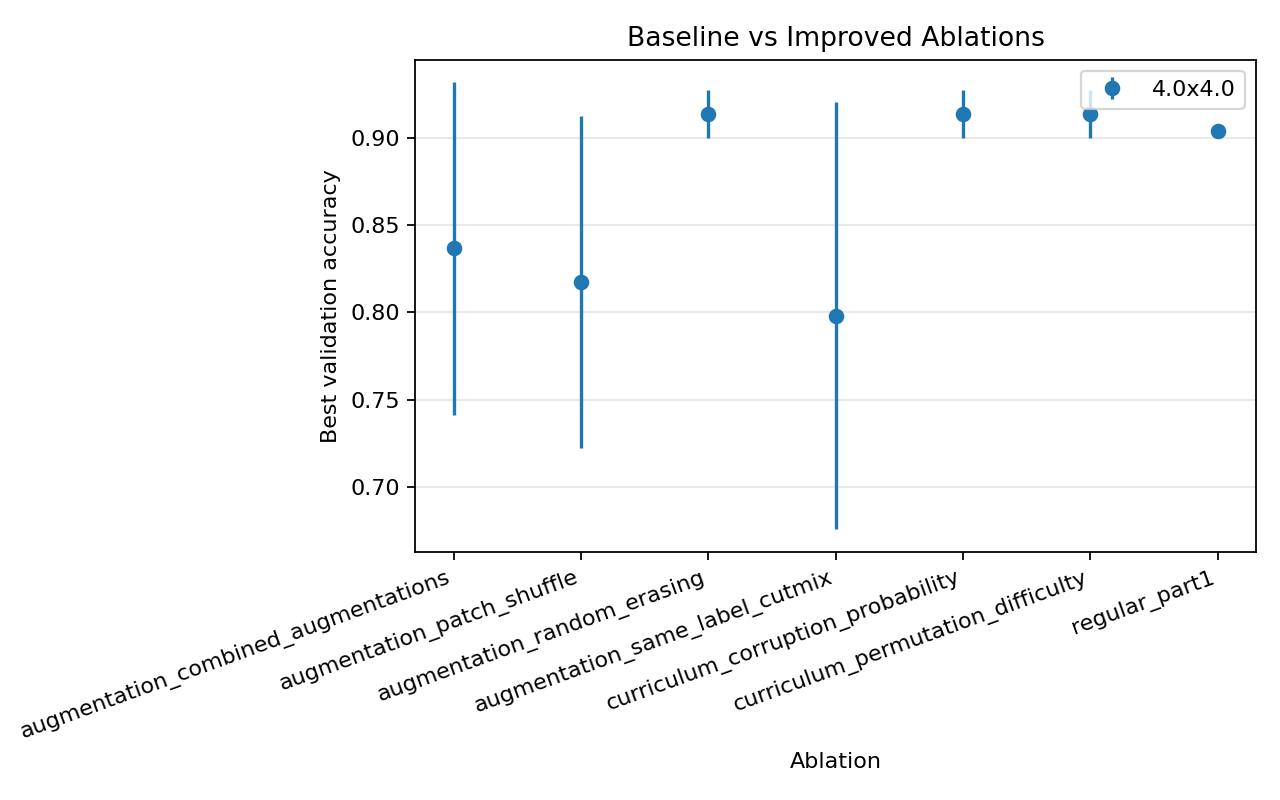

In [10]:
figure_path = Path(output_paths['figure'])
if figure_path.exists():
    display(Image(filename=str(figure_path)))
else:
    print('Part 2 ablation figure has not been generated yet.')

In [11]:
# Export this saved notebook to PDF. Save the notebook before running this cell,
# because nbconvert reads the on-disk .ipynb file rather than unsaved editor state.
import subprocess

notebook_path = ROOT / 'src' / 'notebooks' / 'part2_solution.ipynb'
export_dir = ROOT / 'outputs' / 'notebooks'
export_dir.mkdir(parents=True, exist_ok=True)

try:
    subprocess.run(
        [
            sys.executable,
            '-m',
            'jupyter',
            'nbconvert',
            '--to',
            'pdf',
            str(notebook_path),
            '--output-dir',
            str(export_dir),
        ],
        check=True,
    )
    print(f'Generated PDF: {export_dir / notebook_path.with_suffix(".pdf").name}')
except subprocess.CalledProcessError as exc:
    print('PDF export failed. Confirm the notebook is saved and that nbconvert plus LaTeX are installed.')
    print(f'Command exited with status {exc.returncode}.')


[NbConvertApp] Converting notebook /Users/royrubin/Documents/GitHub/MLDS_Final_Project/src/notebooks/part2_solution.ipynb to pdf
[NbConvertApp] Writing 35226 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 41548 bytes to /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/notebooks/part2_solution.pdf


Generated PDF: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/notebooks/part2_solution.pdf
